# Bai thuc hanh 3

## Vi du 1: Su dung do thi
- Xac dinhj nghiem cua phuong trinh tren [0, 5]
- f(x) = sin(10x) + cos(3x)
- nx: phung phap do thi se khong tim duoc nghiem chinh xac 

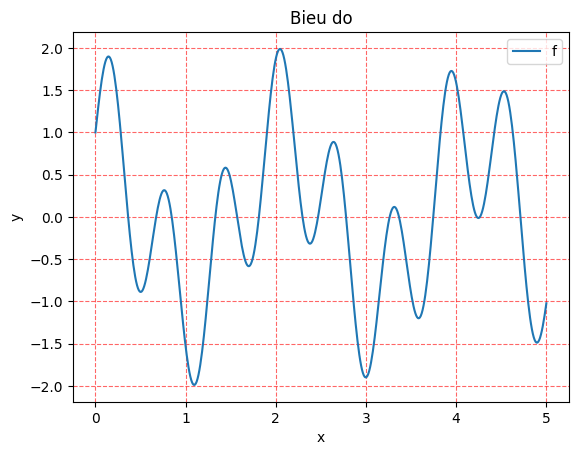

In [2]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(0, 5, 500)
f = np.sin(10*x) + np.cos(3*x)
plt.plot(x, f)
plt.grid(True, linestyle = '--', alpha = 0.6, color = 'red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Bieu do")
plt.legend("f = sin10x + cos3x")
plt.show()

## Vi du 2: Dung phuong phap chia doi
- Tim xap xi nghiem cua phuong trinh x^3 - x + 3 = 0 
- voi sai so tuong doi xap xi khong vuot qua 0.05 

In [2]:
import math
import sympy as sp 


In [4]:
# check khoang phan ly

def check_phanly(f, df, a, b):
    print("\n2. Kiểm tra khoảng phân ly")
    print("f(", a, ")", round(f(a),6))
    print("f(", b, ")", round(f(b),6))
    if f(a)*f(b) < 0:
        print("f(", a, ")", "*", "f(", b, ")<0")
        print("Phương trình f(x) = 0 co nghiem trong khoang (", a, "," , b, ")")
    else:
        print("f(", a, ")", "*", "f(", b, ")>0")
        print("Phương trình f(x) = 0 khong co nghiem trong khoang (", a, "," , b, ")")

    if df(a) > 0 and df(b) > 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu tang") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    elif f(a) < 0 and df(b) < 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu giam ") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    else:
        print("Dung bang bien thien")


In [16]:
# Su dung phuong chia doi 
# In tiêu đề bảng

def divide(f, a, b, tol):
    print("\n")
    print("\n Ta co bang sau:")
    print(f"{'n':<3} {'a':<10} {'b':<10} {'(a+b)/2':<12} {'f((a+b)/2)':<12} {'ε_r':<10}")
    print("-"*60)
    n = 0
    x_old = None
    while True:
        n += 1
        mid = (a + b)  / 2
        f_mid = f(mid)
        
        # Tinh sai so tuong doi neu co gia tri truoc
        if x_old is None: 
            eps_r = "-"
        else:
            eps_r = abs(mid - x_old) / abs(mid)
        # In dòng bảng
        print(f"{n:<3} {a:<10.6f} {b:<10.6f} {mid:<12.6f} {f_mid:<12.6f} {eps_r:<10}")
        
        if x_old is not None and eps_r <= tol:
            break
        
        if (f(a) * f_mid) < 0:
            b = mid
        else:
            a = mid
        
        x_old = mid
    
    print("\n Nghiem xap xi cua phuong trinh la: ", mid)
    print("\n so buoc lap la: ", n)

In [19]:
# khai báo biến
x = sp.symbols('x')

# hàm bài toán
f = x**3 - x + 3

# đạo hàm
df = sp.diff(f, x)


# chuyển sang hàm số để tính
f_num = sp.lambdify(x, f, "math")
df_num = sp.lambdify(x, df, "math")

# khoảng
a = -2
b = -1
eps = 0.005

print("1. Hàm số")
print("f(x) =", f)
print("f'(x) =", df)

check_phanly(f_num, df_num, a, b)
divide(f_num, a, b, eps)


1. Hàm số
f(x) = x**3 - x + 3
f'(x) = 3*x**2 - 1

2. Kiểm tra khoảng phân ly
f( -2 ) -3
f( -1 ) 3
f( -2 ) * f( -1 )<0
Phương trình f(x) = 0 co nghiem trong khoang ( -2 , -1 )
f'(x) > 0 voi moi x thuoc ( -2 , -1 )
f(x) la day don dieu tang
khoang ( -2 , -1 ) la khoang phan ly nghiem cua phuong trinh f(x) = 0



 Ta co bang sau:
n   a          b          (a+b)/2      f((a+b)/2)   ε_r       
------------------------------------------------------------
1   -2.000000  -1.000000  -1.500000    1.125000     -         
2   -2.000000  -1.500000  -1.750000    -0.609375    0.14285714285714285
3   -1.750000  -1.500000  -1.625000    0.333984     0.07692307692307693
4   -1.750000  -1.625000  -1.687500    -0.117920    0.037037037037037035
5   -1.687500  -1.625000  -1.656250    0.112885     0.018867924528301886
6   -1.687500  -1.656250  -1.671875    -0.001293    0.009345794392523364
7   -1.671875  -1.656250  -1.664062    0.056100     0.004694835680751174

 Nghiem xap xi cua phuong trinh la:  -1.6640625

## Vi du 3: Dung phuong phap vi tri gia (Phuong phap day cung) 
- Xac dinh sai so khong vuot qua 0.001 cho nghiem cua phuong trinh x^3 - x + 3 tren doan [-2, -1,5]


In [21]:
import math
import sympy as sp

In [22]:
# check khoang phan ly

def check_phanly(f, df, a, b):
    print("\n2. Kiểm tra khoảng phân ly")
    print("f(", a, ")", round(f(a),6))
    print("f(", b, ")", round(f(b),6))
    if f(a)*f(b) < 0:
        print("f(", a, ")", "*", "f(", b, ")<0")
        print("Phương trình f(x) = 0 co nghiem trong khoang (", a, "," , b, ")")
    else:
        print("f(", a, ")", "*", "f(", b, ")>0")
        print("Phương trình f(x) = 0 khong co nghiem trong khoang (", a, "," , b, ")")

    if df(a) > 0 and df(b) > 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu tang") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    elif f(a) < 0 and df(b) < 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu giam ") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    else:
        print("Dung bang bien thien")


In [24]:
# check khong doi dau:
# check f', f'' khong doi dau tren doan a, b
def check_khongdoidau(df, dff, a, b):
    if df(a)*df(b) > 0: 
        print("f'(x) > 0 voi moi x trong khoang (", a, "," , b, ") nen f'(x) khong doi dau tren (", a, "," , b, ")")
    elif df(a)*df(b) < 0:
        print("f'(x) doi dau tren khoang (", a, "," , b, ")")

    if dff(a)*dff(b) > 0: 
        print("f''(x) > 0 voi moi x trong khoang (", a, "," , b, ") nen f'(x) khong doi dau tren (", a, "," , b, ")")
    elif dff(a)*dff(b) < 0:
        print("f''(x) doi dau tren khoang (", a, "," , b, ")")

In [36]:
# Phuong phap day cung
def daycung_method(f, x0, x1, eps):
    print("\n3. Áp dụng phương pháp dây cung (Secant Method)")
    print(f"{'n':<5}{'x_n-1':<12}{'x_n':<12}{'x_n+1':<12}{'Sai so':<12}")
    n = 0
    while True:
        f_x0 = f(x0)
        f_x1 = f(x1)
        
        # Công thức dây cung
        x2 = x1 - f_x1*(x1 - x0)/(f_x1 - f_x0)
        
        # Sai số tương đối
        if n == 0:
            error = None
        else:
            error = abs(x2 - x1) / abs(x2)
        
        # In bảng
        if error is None:
            print(f"{n:<5}{x0:<12.6f}{x1:<12.6f}{x2:<12.6f}{'-':<12}")
        else:
            print(f"{n:<5}{x0:<12.6f}{x1:<12.6f}{x2:<12.6f}{error:<12.6f}")
        
        # Kiểm tra sai số
        if error is not None and error < eps:
            print(f"\nĐã đạt sai số {error:.6f} < {eps}")
            break
        
        # Cập nhật cho lần lặp tiếp theo
        x0, x1 = x1, x2
        n += 1
    
    print(f"\nNghiệm xấp xỉ: {x2:.6f}")
    print(f"Số lần lặp: {n}")
        

In [37]:
# khai báo biến
x = sp.symbols('x')

# hàm bài toán
f = x**3 - x + 3

# đạo hàm
df = sp.diff(f, x)
ddf = sp.diff(df, x)

# chuyển sang hàm số để tính
f_num = sp.lambdify(x, f, "math")
df_num = sp.lambdify(x, df, "math")
ddf_num = sp.lambdify(x, ddf, "math")

# khoảng
a = -2
b = -1.5
eps = 0.001

print("1. Hàm số")
print("f(x) =", f)
print("f'(x) =", df)
print("f''(x) =", ddf)

check_phanly(f_num, df_num, a, b)
check_khongdoidau(df_num, ddf_num, a, b)

daycung_method(f_num, a, b, eps)



1. Hàm số
f(x) = x**3 - x + 3
f'(x) = 3*x**2 - 1
f''(x) = 6*x

2. Kiểm tra khoảng phân ly
f( -2 ) -3
f( -1.5 ) 1.125
f( -2 ) * f( -1.5 )<0
Phương trình f(x) = 0 co nghiem trong khoang ( -2 , -1.5 )
f'(x) > 0 voi moi x thuoc ( -2 , -1.5 )
f(x) la day don dieu tang
khoang ( -2 , -1.5 ) la khoang phan ly nghiem cua phuong trinh f(x) = 0
f'(x) > 0 voi moi x trong khoang ( -2 , -1.5 ) nen f'(x) khong doi dau tren ( -2 , -1.5 )
f''(x) > 0 voi moi x trong khoang ( -2 , -1.5 ) nen f'(x) khong doi dau tren ( -2 , -1.5 )

3. Áp dụng phương pháp dây cung (Secant Method)
n    x_n-1       x_n         x_n+1       Sai so      
0    -2.000000   -1.500000   -1.636364   -           
1    -1.500000   -1.636364   -1.676271   0.023807    
2    -1.636364   -1.676271   -1.671589   0.002801    
3    -1.676271   -1.671589   -1.671700   0.000066    

Đã đạt sai số 0.000066 < 0.001

Nghiệm xấp xỉ: -1.671700
Số lần lặp: 3


Bài luyện tập
- Cho phương trình 
- (1) Đưa ra bảng giá trị của hàm vế trái để dự đoán khoảng chứa nghiệm
- (2) Vẽ đồ thị để chọn khoảng có nghiệm.
-  (3) Xác định nghiệm chính xác của phương trình
- (4) Sử dụng phương pháp chia đôi, tìm nghiệm xấp xỉ cho tới khi sai số tương đối xấp xỉ nhỏ hơn dung sai εs = 0.5%, so sánh với sai số tương đối thực.
- (5) Vẽ đồ thị của sai số tương đối xấp xỉ và đồ thị của sai số tương đối thực trên cùng một hình.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [63]:
# check khoang phan ly

def check_phanly(f, df, a, b):
    print("\n2. Kiểm tra khoảng phân ly")
    print("f(", a, ")", round(f(a),6))
    print("f(", b, ")", round(f(b),6))
    if f(a)*f(b) < 0:
        print("f(", a, ")", "*", "f(", b, ")<0")
        print("Phương trình f(x) = 0 co nghiem trong khoang (", a, "," , b, ")")
    else:
        print("f(", a, ")", "*", "f(", b, ")>0")
        print("Phương trình f(x) = 0 khong co nghiem trong khoang (", a, "," , b, ")")

    if df(a) > 0 and df(b) > 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu tang") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    elif f(a) < 0 and df(b) < 0:
        print("f'(x) > 0 voi moi x thuoc (", a, ",", b, ")")
        print("f(x) la day don dieu giam ") 
        print("khoang (", a, "," , b, ") la khoang phan ly nghiem cua phuong trinh f(x) = 0")
    else:
        print("Dung bang bien thien")


In [53]:
# lap bang gia tri 
def create_table(f):
    x_values = np.arange(2, 18, 2)
    print("Bảng giá trị f(x):")
    print(f"{'x':>6} {'f(x)':>10}")
    for x in x_values:
        print(f"{x:6.2f} {f(x):10.4f}")

In [50]:
# Ve do thi de chon khoang co nghiem 
def visualization(f, f_name):
    x_plot = np.linspace(14, 16, 100)
    y_plot = f(x_plot)
    plt.figure(figsize=(8,5))
    plt.plot(x_plot, y_plot, label=f_name)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True)
    plt.title("Đồ thị hàm số f(x)")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()

In [59]:
# Xac dinh nghiem chinh xac cua phuong trinh
def slove_true(f, x0):
    sol = sp.nsolve(f, x, x0)
    print("Nghiem chinh xac la:", sol)

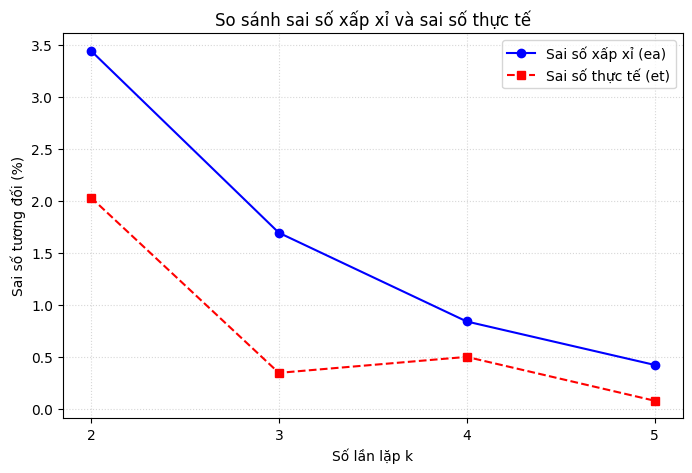

In [60]:
# so sanh ea: sai so xap xi, voi et: sai so tuong doi
import matplotlib.pyplot as plt

# Dữ liệu
k = [2, 3, 4, 5]
ea = [3.4483, 1.6949, 0.8403, 0.4219]  # sai số xấp xỉ
et = [2.0344, 0.3453, 0.4992, 0.0770]  # sai số thực tế

# Tạo figure và vẽ đồ thị
plt.figure(figsize=(8, 5))

# Vẽ sai số xấp xỉ
plt.plot(k, ea, label='Sai số xấp xỉ (ea)', marker='o',
         linestyle='-', color='blue')

# Vẽ sai số thực tế
plt.plot(k, et, label='Sai số thực tế (et)', marker='s',
         linestyle='--', color='red')

# Tiêu đề và nhãn trục
plt.title('So sánh sai số xấp xỉ và sai số thực tế')
plt.xlabel('Số lần lặp k')
plt.ylabel('Sai số tương đối (%)')

# Hiển thị các giá trị k trên trục x
plt.xticks(k)

# Lưới
plt.grid(True, linestyle=':', alpha=0.5)

# Hiển thị chú thích
plt.legend()

# Hiển thị đồ thị
plt.show()

1. Hàm số
f(x) = -40 + 668.06*(1 - exp(-0.146843*x))/x
f'(x) = 98.09993458*exp(-0.146843*x)/x - 668.06*(1 - exp(-0.146843*x))/x**2
f''(x) = -14.4052886935309*exp(-0.146843*x)/x - 196.19986916*exp(-0.146843*x)/x**2 + 1336.12*(1 - exp(-0.146843*x))/x**3
Bảng giá trị f(x):
     x       f(x)
  2.00    45.0071
  4.00    34.1904
  6.00    25.2089
  8.00    17.7122
 10.00    11.4215
 12.00     6.1139
 14.00     1.6111
 16.00    -2.2303


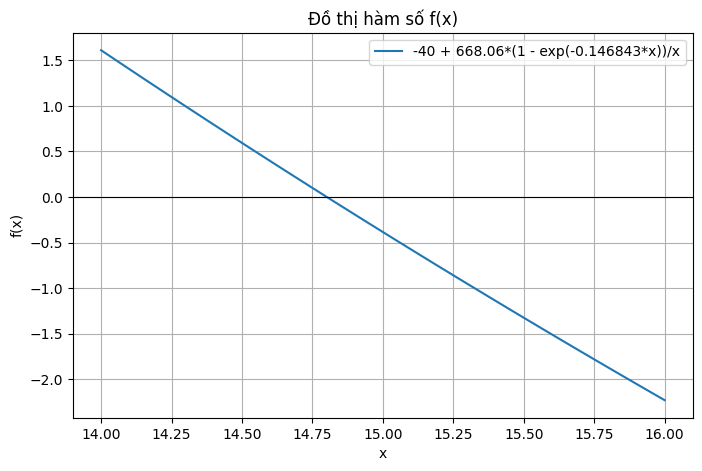

Nghiem chinh xac la: 14.8011099690227

2. Kiểm tra khoảng phân ly
f( -2 ) 74.025366
f( -1.5 ) 69.742823
f( -2 ) * f( -1.5 )>0
Phương trình f(x) = 0 khong co nghiem trong khoang ( -2 , -1.5 )
Dung bang bien thien
f'(x) > 0 voi moi x trong khoang ( -2 , -1.5 ) nen f'(x) khong doi dau tren ( -2 , -1.5 )
f''(x) > 0 voi moi x trong khoang ( -2 , -1.5 ) nen f'(x) khong doi dau tren ( -2 , -1.5 )

3. Áp dụng phương pháp dây cung (Secant Method)
n    x_n-1       x_n         x_n+1       Sai so      
0    -2.000000   -1.500000   6.642687    -           
1    -1.500000   6.642687    10.559705   0.370940    
2    6.642687    10.559705   13.570898   0.221886    
3    10.559705   13.570898   14.605107   0.070811    
4    13.570898   14.605107   14.791769   0.012619    
5    14.605107   14.791769   14.801038   0.000626    

Đã đạt sai số 0.000626 < 0.001

Nghiệm xấp xỉ: 14.801038
Số lần lặp: 5


In [64]:
# khai báo biến
x = sp.symbols('x')

# hàm bài toán
f = 668.06 / x * (1 - sp.exp(-0.146843 * x)) - 40

# đạo hàm
df = sp.diff(f, x)
ddf = sp.diff(df, x)

# chuyển sang hàm số để tính
f_num = sp.lambdify(x, f, "numpy")
df_num = sp.lambdify(x, df, "numpy")
ddf_num = sp.lambdify(x, ddf, "numpy")

# khoảng
a = -2
b = -1.5
eps = 0.001

print("1. Hàm số")
print("f(x) =", f)
print("f'(x) =", df)
print("f''(x) =", ddf)

create_table(f_num)
visualization(f_num, f)
slove_true(f, 14)
check_phanly(f_num, df_num, a, b)
check_khongdoidau(df_num, ddf_num, a, b)

daycung_method(f_num, a, b, eps)



# Bai tap: 143: 5.1 - 5.4

## 5.1: Xac dinh cac nghiem thuc cua ham so 
- f(x) = $f(x) = -0.6x^2 + 2.4x + 5.5$:
- a, bang phuong phap đồ thị
- b, sử dụng công thức nghiệm ptrinh bậc 2
- c, sử udngj 3 lần lặp của phương pháp chia đôi, x1 = 5, x2 = 10. Tinhs toán sai số ướng lượng xấp xỉ và sai số tương đối


In [79]:
#a. Su dung phuong phap do thi
# lap bang gia tri 
def create_table(f):
    x_values = np.arange(2, 18, 2)
    print("Bảng giá trị f(x):")
    print(f"{'x':>6} {'f(x)':>10}")
    for x in x_values:
        print(f"{x:6.2f} {f(x):10.4f}")
        
# Ve do thi de chon khoang co nghiem 
def visualization(f, f_name):
    x_plot = np.linspace(2, 12, 100)
    y_plot = f(x_plot)
    plt.figure(figsize=(8,5))
    plt.plot(x_plot, y_plot, label=f_name)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.grid(True)
    plt.title("Đồ thị hàm số f(x)")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.legend()
    plt.show()
    
# Xac dinh nghiem chinh xac cua phuong trinh
def slove_true(f, x0):
    sol = sp.nsolve(f, x, x0)
    print("Nghiem chinh xac la:", sol)
    return sol

In [ ]:
# Su dung phuong chia doi 
# In tiêu đề bảng

def divide(f, a, b, tol, x_true):
    print("\n")
    print("\n Ta co bang sau:")
    print(f"{'n':<3} {'a':<10} {'b':<10} {'(a+b)/2':<12} {'f((a+b)/2)':<12} {'ε_a':<10} {'ε_t':<10}")
    print("-"*60)
    n = 0
    x_old = None
    while True:
        n += 1
        mid = (a + b)  / 2
        f_mid = f(mid)
        
        eps_t = abs((x_true - mid) / x_true)*100
        # Tinh sai so tuong doi neu co gia tri truoc
        if x_old is None: 
            eps_a = "-"
        else:
            eps_a = abs(mid - x_old) / abs(mid)
        # In dòng bảng
        print(f"{n:<3} {a:<10.6f} {b:<10.6f} {mid:<12.6f} {f_mid:<12.6f} {eps_a:<10} {eps_t:<10}")
        
        if x_old is not None and eps_a <= tol:
            break
        
        if (f(a) * f_mid) < 0:
            b = mid
        else:
            a = mid
        
        x_old = mid
    
    print("\n Nghiem xap xi cua phuong trinh la: ", mid)
    print("\n so buoc lap la: ", n)

1. Hàm số
f(x) = -0.6*x**2 + 2.4*x + 5.5
f'(x) = 2.4 - 1.2*x
f''(x) = -1.20000000000000
Bảng giá trị f(x):
     x       f(x)
  2.00     7.9000
  4.00     5.5000
  6.00    -1.7000
  8.00   -13.7000
 10.00   -30.5000
 12.00   -52.1000
 14.00   -78.5000
 16.00  -109.7000


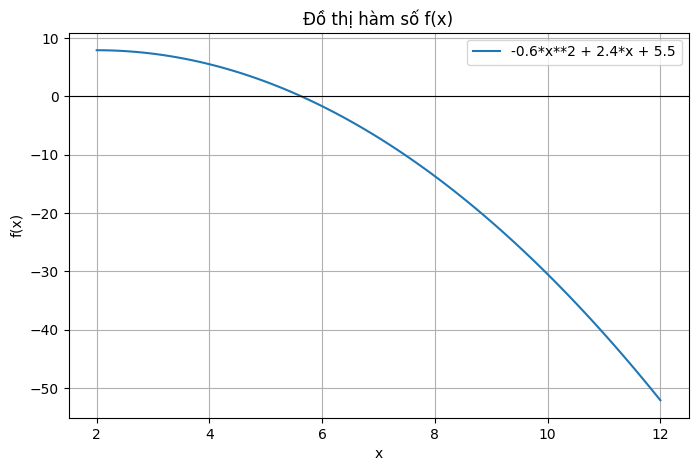

Nghiem chinh xac la: 5.62859017617954

2. Kiểm tra khoảng phân ly
f( 5 ) 2.5
f( 10 ) -30.5
f( 5 ) * f( 10 )<0
Phương trình f(x) = 0 co nghiem trong khoang ( 5 , 10 )
Dung bang bien thien
f'(x) > 0 voi moi x trong khoang ( 5 , 10 ) nen f'(x) khong doi dau tren ( 5 , 10 )
f''(x) > 0 voi moi x trong khoang ( 5 , 10 ) nen f'(x) khong doi dau tren ( 5 , 10 )



 Ta co bang sau:
n   a          b          (a+b)/2      f((a+b)/2)   ε_a        ε_t       
------------------------------------------------------------
1   5.000000   10.000000  7.500000     -10.250000   -          33.2482871419624
2   5.000000   7.500000   6.250000     -2.937500    0.2        11.0402392849686
3   5.000000   6.250000   5.625000     0.015625     0.1111111111111111 0.0637846435282154
4   5.625000   6.250000   5.937500     -1.402344    0.05263157894736842 5.48822732072022
5   5.625000   5.937500   5.781250     -0.678711    0.02702702702702703 2.71222133859600
6   5.625000   5.781250   5.703125     -0.327881    0.0136986

In [81]:
# khai báo biến
x = sp.symbols('x')

# hàm bài toán
f = -0.6*x**2 + 2.4*x + 5.5

# đạo hàm
df = sp.diff(f, x)
ddf = sp.diff(df, x)

# chuyển sang hàm số để tính
f_num = sp.lambdify(x, f, "numpy")
df_num = sp.lambdify(x, df, "numpy")
ddf_num = sp.lambdify(x, ddf, "numpy")

# khoảng
a = 5
b = 10
eps = 0.001

print("1. Hàm số")
print("f(x) =", f)
print("f'(x) =", df)
print("f''(x) =", ddf)

create_table(f_num)
visualization(f_num, f)
x_true = slove_true(f, 6)  # Chon x0 dua vao do thi: tim diem gan nhat lm fx = 0

check_phanly(f_num, df_num, a, b)
check_khongdoidau(df_num, ddf_num, a, b)

divide(f_num, a, b,eps, x_true)



Sai số tương đối thực ($\epsilon_t$): Giảm từ 33.25% xuống còn 0.109% sau 9 bước. Đây là minh chứng cho việc thuật toán đang đi đúng hướng về phía nghiệm thực $x \approx 5.6286$.Sai số xấp xỉ ($\epsilon_a$): Đây là chỉ số quan trọng trong lập trình khi ta không biết nghiệm thực. Bạn có thể thấy $\epsilon_a$ luôn giảm dần, điều này cho thấy nghiệm đang dần ổn định.